<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/00_Longitudinal_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 같은 Master Data로 4가지 분석하기
## Trend · Panel · Cohort · Time Series

이 노트북은 **하나의 공통 원자료 `00_master_same_data.csv`**만 사용하여
다음 네 가지 분석을 모두 수행합니다.

1. **Trend Analysis** — 매 시점의 모집단 평균·분포 변화
2. **Panel Analysis** — 같은 가구의 반복관측과 고정효과
3. **Cohort Analysis** — EV 도입이라는 공통 사건 이후의 경로
4. **Time Series Analysis** — 집계된 하나의 연속 시계열과 예측

### 핵심 아이디어
> 데이터는 하나지만, **무엇을 반복해서 관측하느냐**에 따라 분석 설계가 달라집니다.

- Trend: 반복되는 **모집단 요약**
- Panel: 반복되는 **동일 개체**
- Cohort: 반복되는 **동일 사건 이후의 시간**
- Time Series: 반복되는 **동일 변수의 연속값**

In [1]:
# Colab 기본 패키지 + 필요한 라이브러리
!pip -q install statsmodels scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.formula.api import ols
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

def bilingual(kr, en):
    display(Markdown(f"**[KR]** {kr}<br>**[EN]** {en}"))

# 0. 데이터 불러오기

GitHub에 `00_master_same_data.csv`를 올린 뒤 아래 `RAW_URL`만 수정하면 됩니다.

예를 들어 파일 위치가

`https://github.com/nhjung-phd/TimeSeriesAnalysis/blob/main/examples/00_master_same_data.csv`

라면 RAW URL은:

`https://raw.githubusercontent.com/nhjung-phd/TimeSeriesAnalysis/main/examples/00_master_same_data.csv`

입니다.

노트북과 CSV를 같은 Colab 폴더에 직접 업로드한 경우에는 `USE_GITHUB = False`로 바꾸면 됩니다.

In [3]:
# ===== 사용자 설정 / USER CONFIGURATION =====
USE_GITHUB = True

RAW_URL = "https://raw.githubusercontent.com/nhjung-phd/TimeSeriesAnalysis/main/examples/00_master_same_data.csv"
LOCAL_FILE = "00_master_same_data.csv"
# ===========================================

source = RAW_URL if USE_GITHUB else LOCAL_FILE
df = pd.read_csv(source)

df["month"] = pd.to_datetime(df["month"])
df["ev_adoption_month"] = pd.to_datetime(df["ev_adoption_month"], errors="coerce")

print("shape =", df.shape)
print("households =", df["household_id"].nunique())
print("period =", df["month"].min().date(), "~", df["month"].max().date())
display(df.head())

shape = (7200, 11)
households = 120
period = 2021-01-01 ~ 2025-12-01


,household_id,month,household_size,region,income_group,ev_adoption_month,ev_cohort,post_adoption,months_since_adoption,avg_temperature_c,electricity_kwh
0,H001,2021-01-01,3,Seoul,Middle,2024-09-01,2024Q3,0,-44.0,0.77,237.40
1,H002,2021-01-01,1,Daegu,Low,2022-09-01,2022Q3,0,-20.0,0.77,226.33
2,H003,2021-01-01,3,Gyeonggi,Middle,NaT,NaN,0,NaN,0.77,266.90
3,H004,2021-01-01,2,Seoul,High,2023-06-01,2023Q2,0,-29.0,0.77,257.49
4,H005,2021-01-01,2,Gyeonggi,High,2023-10-01,2023Q4,0,-33.0,0.77,284.75


In [4]:
# 기본 점검
expected_cols = [
    "household_id","month","household_size","region","income_group",
    "ev_adoption_month","ev_cohort","post_adoption","months_since_adoption",
    "avg_temperature_c","electricity_kwh"
]

missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2)
})
display(quality)

bilingual(
    "ev_adoption_month와 ev_cohort의 결측은 EV 미도입 가구를 의미하므로 오류가 아닙니다.",
    "Missing values in ev_adoption_month and ev_cohort indicate non-adopting households and are not data errors."
)

,dtype,missing_n,missing_pct
household_id,object,0,0.00
month,datetime64[ns],0,0.00
household_size,int64,0,0.00
region,object,0,0.00
income_group,object,0,0.00
ev_adoption_month,datetime64[ns],3480,48.33
ev_cohort,object,3480,48.33
post_adoption,int64,0,0.00
months_since_adoption,float64,3480,48.33
avg_temperature_c,float64,0,0.00


**[KR]** ev_adoption_month와 ev_cohort의 결측은 EV 미도입 가구를 의미하므로 오류가 아닙니다.<br>**[EN]** Missing values in ev_adoption_month and ev_cohort indicate non-adopting households and are not data errors.

---
# 1. Trend Analysis
## 모집단 평균·분포가 시간에 따라 어떻게 변하는가?

Trend Analysis에서는 동일 가구 ID 자체가 핵심이 아닙니다.
각 월의 **전체 모집단 수준(mean, median, distribution)** 이 어떻게 변하는지를 봅니다.

In [5]:
trend = (
    df.groupby("month")
      .agg(
          n_households=("household_id","nunique"),
          mean_kwh=("electricity_kwh","mean"),
          median_kwh=("electricity_kwh","median"),
          p25_kwh=("electricity_kwh", lambda x: x.quantile(.25)),
          p75_kwh=("electricity_kwh", lambda x: x.quantile(.75)),
          avg_temperature_c=("avg_temperature_c","mean")
      )
      .reset_index()
)

display(trend.head())

,month,n_households,mean_kwh,median_kwh,p25_kwh,p75_kwh,avg_temperature_c
0,2021-01-01,120,270.029417,260.620,235.5550,309.4150,0.77
1,2021-02-01,120,257.420250,253.350,222.6950,286.9150,-0.28
2,2021-03-01,120,243.959583,242.315,215.9075,265.1000,3.41
3,2021-04-01,120,229.959333,230.795,196.9275,265.0925,7.93
4,2021-05-01,120,233.992917,233.190,207.0300,258.9325,13.26


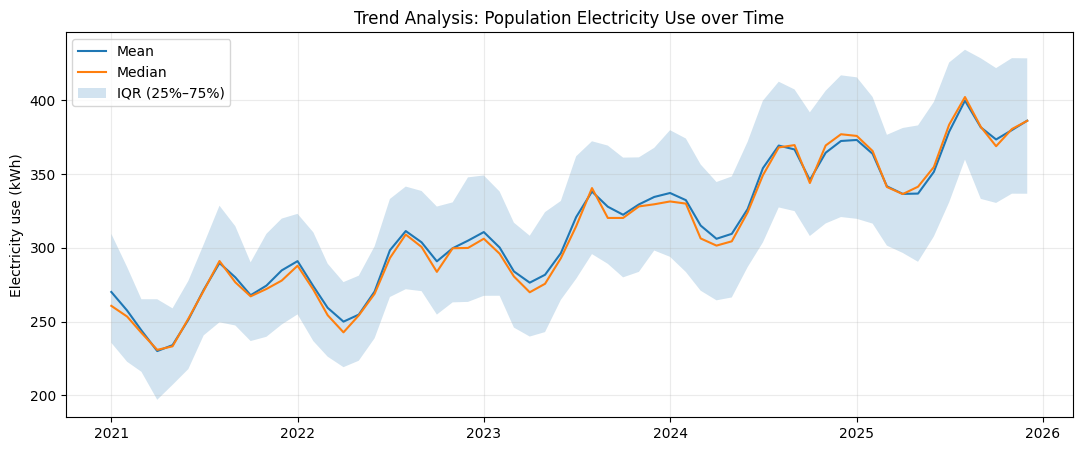

In [6]:
plt.figure(figsize=(13,5))
plt.plot(trend["month"], trend["mean_kwh"], label="Mean")
plt.plot(trend["month"], trend["median_kwh"], label="Median")
plt.fill_between(
    trend["month"],
    trend["p25_kwh"],
    trend["p75_kwh"],
    alpha=0.20,
    label="IQR (25%–75%)"
)
plt.title("Trend Analysis: Population Electricity Use over Time")
plt.ylabel("Electricity use (kWh)")
plt.legend()
plt.show()

In [7]:
# 계절효과를 통제한 장기 추세 회귀
trend["time_idx"] = np.arange(len(trend))
trend["calendar_month"] = trend["month"].dt.month.astype(str)

trend_model = ols(
    "mean_kwh ~ time_idx + C(calendar_month)",
    data=trend
).fit()

coef = trend_model.params["time_idx"]
pval = trend_model.pvalues["time_idx"]

print(trend_model.summary().tables[1])

bilingual(
    f"월별 계절성을 통제한 후 장기 추세계수는 월당 {coef:.2f} kWh이며 p-value는 {pval:.4g}입니다.",
    f"After controlling for calendar-month seasonality, the long-run trend coefficient is {coef:.2f} kWh per month with p-value {pval:.4g}."
)

                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 263.2409      2.062    127.638      0.000     259.092     267.390
C(calendar_month)[T.10]   -16.2222      2.716     -5.973      0.000     -21.686     -10.758
C(calendar_month)[T.11]    -8.9709      2.720     -3.298      0.002     -14.442      -3.499
C(calendar_month)[T.12]    -4.2113      2.724     -1.546      0.129      -9.691       1.268
C(calendar_month)[T.2]    -13.0902      2.701     -4.847      0.000     -18.523      -7.657
C(calendar_month)[T.3]    -32.0187      2.701    -11.854      0.000     -37.453     -26.585
C(calendar_month)[T.4]    -43.2484      2.702    -16.006      0.000     -48.684     -37.813
C(calendar_month)[T.5]    -41.9195      2.703    -15.506      0.000     -47.358     -36.481
C(calendar_month)[T.6]    -28.3179      2.705    -10.468      0.000     -33.760 

**[KR]** 월별 계절성을 통제한 후 장기 추세계수는 월당 2.21 kWh이며 p-value는 1.201e-48입니다.<br>**[EN]** After controlling for calendar-month seasonality, the long-run trend coefficient is 2.21 kWh per month with p-value 1.201e-48.

### Trend Analysis 해석
- 분석단위: 월별 모집단 요약치
- 핵심 질문: **전체 수준이 장기적으로 증가·감소하는가?**
- 동일 개체 추적이 핵심은 아님
- 결과: 장기 추세, 계절성, 분포 변화

---
# 2. Panel Analysis
## 같은 가구가 시간에 따라 어떻게 변하는가?

Panel Analysis에서는 `household_id`가 핵심입니다.
동일한 가구를 여러 시점에 반복 관측하기 때문에
가구 고유의 관측되지 않는 특성을 **fixed effect**로 통제할 수 있습니다.

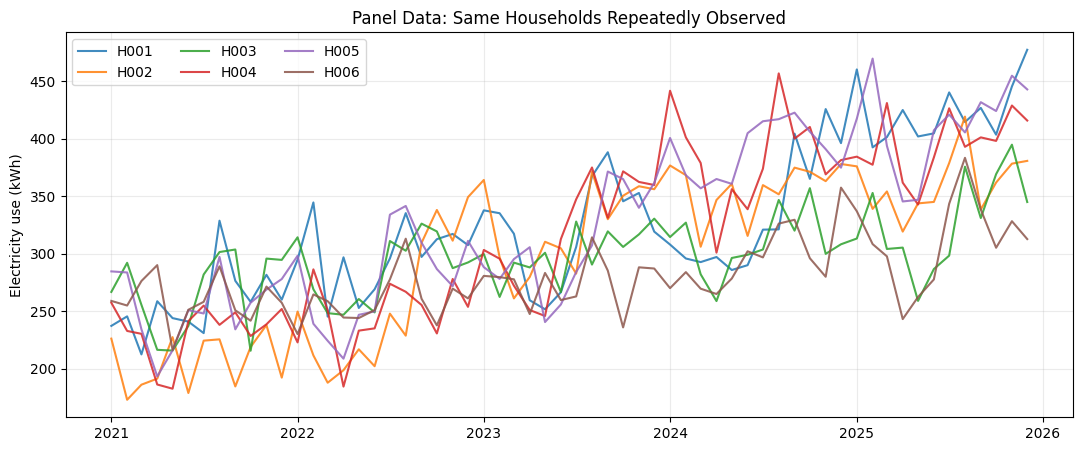

In [8]:
# 임의 6개 가구의 반복관측 시각화
sample_ids = df["household_id"].drop_duplicates().head(6)

plt.figure(figsize=(13,5))
for hid in sample_ids:
    tmp = df[df["household_id"] == hid]
    plt.plot(tmp["month"], tmp["electricity_kwh"], label=hid, alpha=0.85)

plt.title("Panel Data: Same Households Repeatedly Observed")
plt.ylabel("Electricity use (kWh)")
plt.legend(ncol=3)
plt.show()

In [9]:
# Panel Fixed Effects
# household FE + calendar-month seasonality + long-run trend
# EV adoption 이후 변화(post_adoption)를 추정

panel = df.copy()
panel["time_idx"] = (
    (panel["month"].dt.year - panel["month"].dt.year.min()) * 12
    + panel["month"].dt.month - panel["month"].dt.month.min()
)
panel["calendar_month"] = panel["month"].dt.month.astype(str)
panel["temp_sq"] = panel["avg_temperature_c"] ** 2

fe_model = ols(
    "electricity_kwh ~ post_adoption + time_idx "
    "+ avg_temperature_c + temp_sq "
    "+ C(calendar_month) + C(household_id)",
    data=panel
).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel["household_id"]}
)

effect = fe_model.params["post_adoption"]
se = fe_model.bse["post_adoption"]
pval = fe_model.pvalues["post_adoption"]

panel_result = pd.DataFrame({
    "estimate": [effect],
    "clustered_se": [se],
    "p_value": [pval]
}, index=["post_adoption"])

display(panel_result.round(4))

bilingual(
    f"가구 고정효과, 장기 추세, 월 계절성, 기온 효과를 통제한 후 EV 도입 이후 전력사용량 변화는 약 {effect:.1f} kWh로 추정됩니다.",
    f"After controlling for household fixed effects, long-run trend, seasonality, and temperature, electricity use after EV adoption is estimated to change by about {effect:.1f} kWh."
)

,estimate,clustered_se,p_value
post_adoption,85.9906,1.0311,0.0


**[KR]** 가구 고정효과, 장기 추세, 월 계절성, 기온 효과를 통제한 후 EV 도입 이후 전력사용량 변화는 약 86.0 kWh로 추정됩니다.<br>**[EN]** After controlling for household fixed effects, long-run trend, seasonality, and temperature, electricity use after EV adoption is estimated to change by about 86.0 kWh.

### Panel Analysis 해석
- 분석단위: **가구 × 월**
- 핵심 질문: 같은 가구 내부에서 시간이 지나며 무엇이 바뀌는가?
- 장점: 시간불변의 개체 특성을 통제 가능
- 대표방법: FE, RE, Dynamic Panel

---
# 3. Cohort Analysis
## 같은 사건을 경험한 집단은 이후 어떻게 변하는가?

Cohort Analysis에서는 달력시간보다 **사건으로부터 얼마나 시간이 지났는가**가 중요합니다.

이 데이터에서는 공통 사건을 **EV 도입**으로 설정합니다.

- Event time = 0 : EV 도입월
- -12 : 도입 12개월 전
- +12 : 도입 12개월 후

In [10]:
adopters = df[df["ev_adoption_month"].notna()].copy()

event = adopters[
    adopters["months_since_adoption"].between(-12, 12)
].copy()

# 가구별 도입 직전(-3,-2,-1개월) 평균을 baseline으로 사용
baseline = (
    event[event["months_since_adoption"].between(-3,-1)]
    .groupby("household_id")["electricity_kwh"]
    .mean()
    .rename("baseline_kwh")
)

event = event.join(baseline, on="household_id")
event["delta_from_baseline"] = (
    event["electricity_kwh"] - event["baseline_kwh"]
)

cohort = (
    event.groupby(["ev_cohort","months_since_adoption"])
         .agg(
             mean_delta=("delta_from_baseline","mean"),
             n_households=("household_id","nunique")
         )
         .reset_index()
)

display(cohort.head())

,ev_cohort,months_since_adoption,mean_delta,n_households
0,2022Q1,-12.0,-22.307778,3
1,2022Q1,-11.0,-42.757778,3
2,2022Q1,-10.0,-28.261111,3
3,2022Q1,-9.0,-42.011111,3
4,2022Q1,-8.0,-23.741111,3


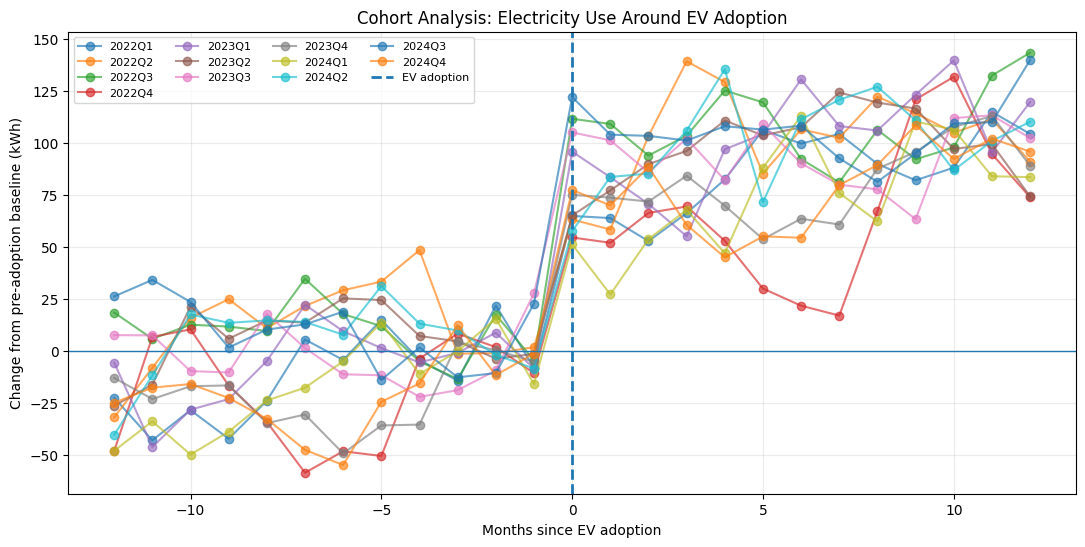

In [11]:
plt.figure(figsize=(13,6))

for cohort_name, tmp in cohort.groupby("ev_cohort"):
    plt.plot(
        tmp["months_since_adoption"],
        tmp["mean_delta"],
        marker="o",
        alpha=0.65,
        label=cohort_name
    )

plt.axvline(0, linestyle="--", linewidth=2, label="EV adoption")
plt.axhline(0, linewidth=1)
plt.title("Cohort Analysis: Electricity Use Around EV Adoption")
plt.xlabel("Months since EV adoption")
plt.ylabel("Change from pre-adoption baseline (kWh)")
plt.legend(ncol=4, fontsize=8)
plt.show()

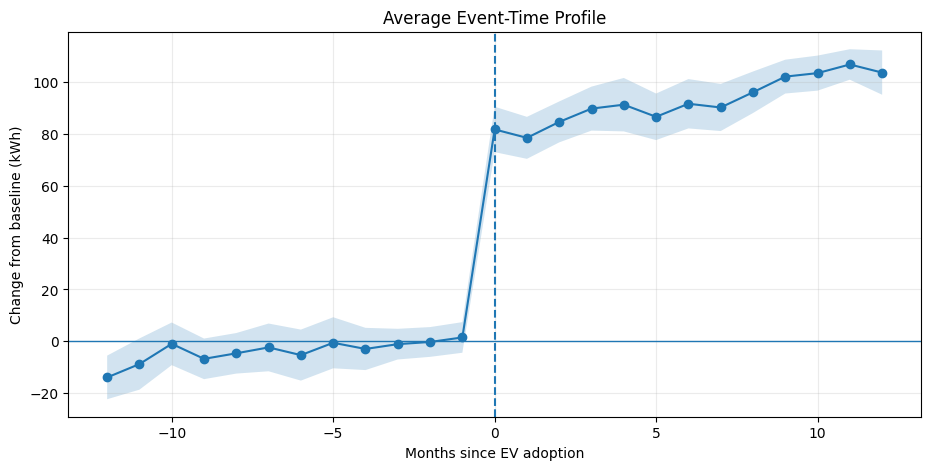

In [12]:
# 모든 EV 도입가구를 합친 평균 event-time profile
overall_event = (
    event.groupby("months_since_adoption")
         .agg(
             mean_delta=("delta_from_baseline","mean"),
             se=("delta_from_baseline","sem"),
             n=("household_id","nunique")
         )
         .reset_index()
)

overall_event["ci_low"] = overall_event["mean_delta"] - 1.96*overall_event["se"]
overall_event["ci_high"] = overall_event["mean_delta"] + 1.96*overall_event["se"]

plt.figure(figsize=(11,5))
plt.plot(
    overall_event["months_since_adoption"],
    overall_event["mean_delta"],
    marker="o"
)
plt.fill_between(
    overall_event["months_since_adoption"],
    overall_event["ci_low"],
    overall_event["ci_high"],
    alpha=0.2
)
plt.axvline(0, linestyle="--")
plt.axhline(0, linewidth=1)
plt.title("Average Event-Time Profile")
plt.xlabel("Months since EV adoption")
plt.ylabel("Change from baseline (kWh)")
plt.show()

### Cohort Analysis 해석
- 분석단위: 동일한 사건을 경험한 집단
- 핵심 시간축: **calendar time이 아니라 event time**
- 질문: EV 도입 전후 경로가 어떻게 달라지는가?
- 주의: 이것만으로 인과효과라고 단정할 수는 없음  
  (비교집단·parallel trend·event study 설계가 추가로 필요)

---
# 4. Time Series Analysis
## 하나의 연속된 시계열은 어떤 구조를 가지는가?

가구 수준 자료를 월별 평균으로 집계하여
**하나의 연속 시계열**로 변환합니다.

이제 개체 ID는 분석의 중심이 아니며,
추세·계절성·자기상관·예측이 핵심이 됩니다.

In [13]:
ts = (
    df.groupby("month")
      .agg(
          mean_kwh=("electricity_kwh","mean"),
          total_kwh=("electricity_kwh","sum"),
          avg_temperature_c=("avg_temperature_c","mean")
      )
      .asfreq("MS")
)

display(ts.head())

,mean_kwh,total_kwh,avg_temperature_c
month,,,
2021-01-01,270.029417,32403.53,0.77
2021-02-01,257.420250,30890.43,-0.28
2021-03-01,243.959583,29275.15,3.41
2021-04-01,229.959333,27595.12,7.93
2021-05-01,233.992917,28079.15,13.26


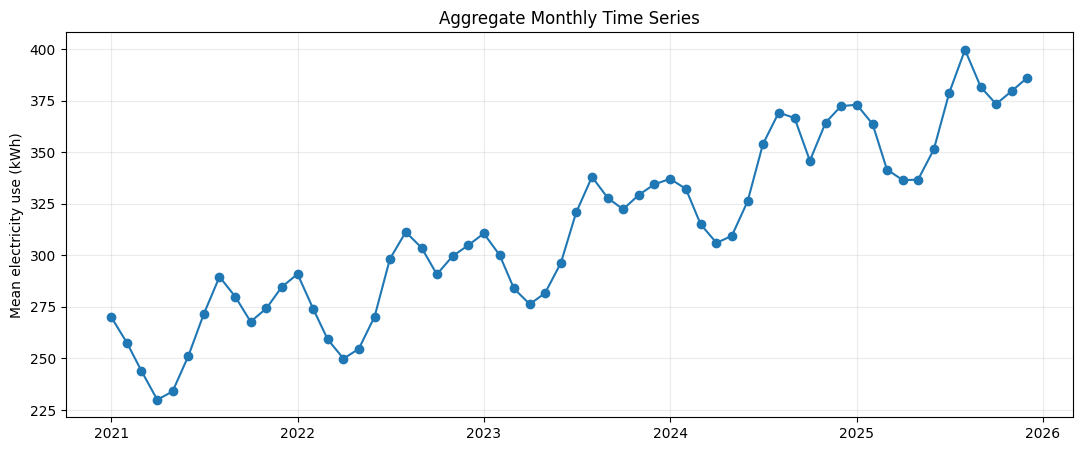

In [14]:
plt.figure(figsize=(13,5))
plt.plot(ts.index, ts["mean_kwh"], marker="o")
plt.title("Aggregate Monthly Time Series")
plt.ylabel("Mean electricity use (kWh)")
plt.show()

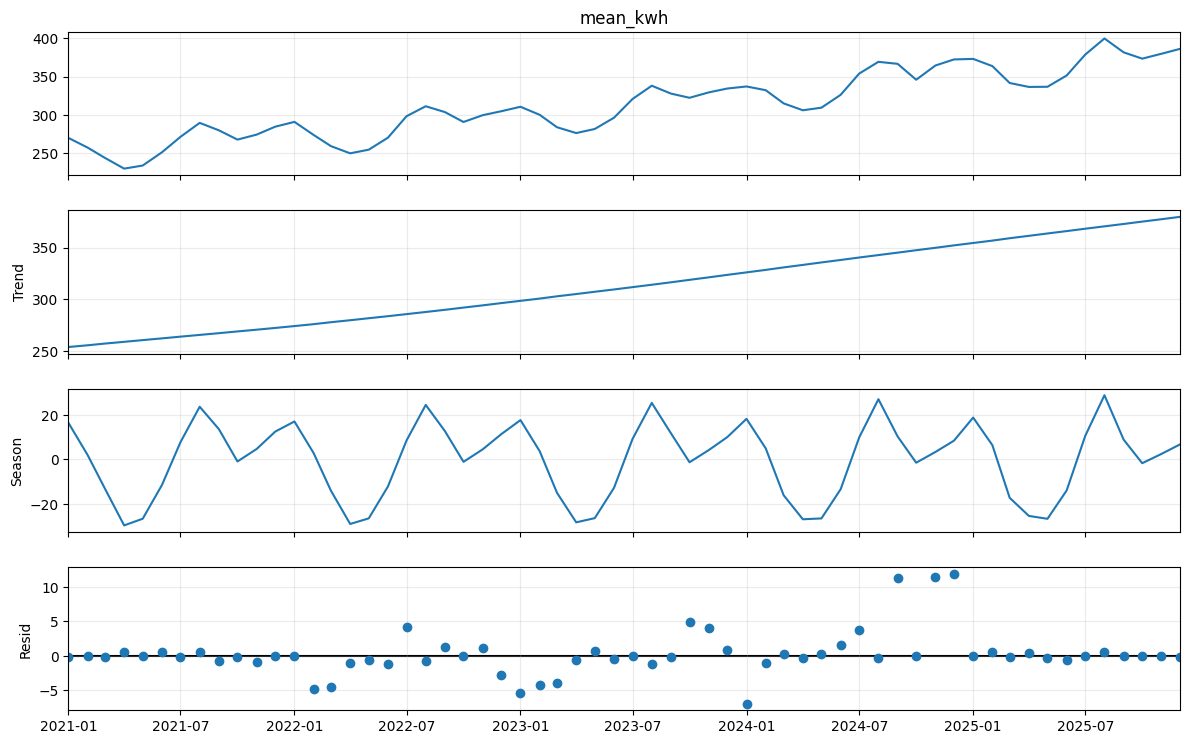

In [15]:
# STL decomposition
stl = STL(ts["mean_kwh"], period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12,8)
plt.show()

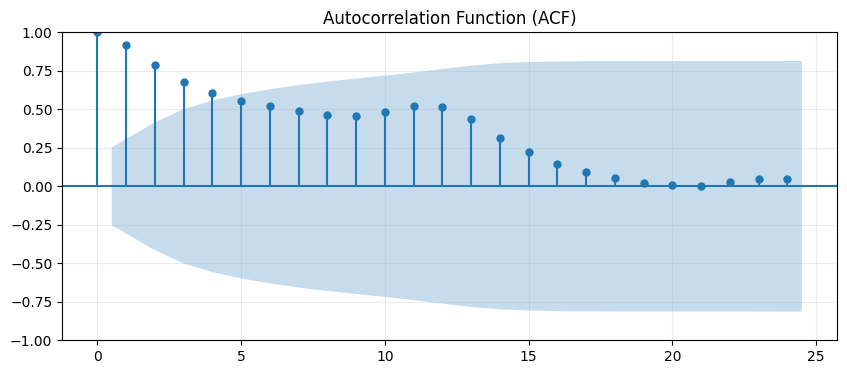

In [16]:
# ACF
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts["mean_kwh"], lags=24, ax=ax)
ax.set_title("Autocorrelation Function (ACF)")
plt.show()

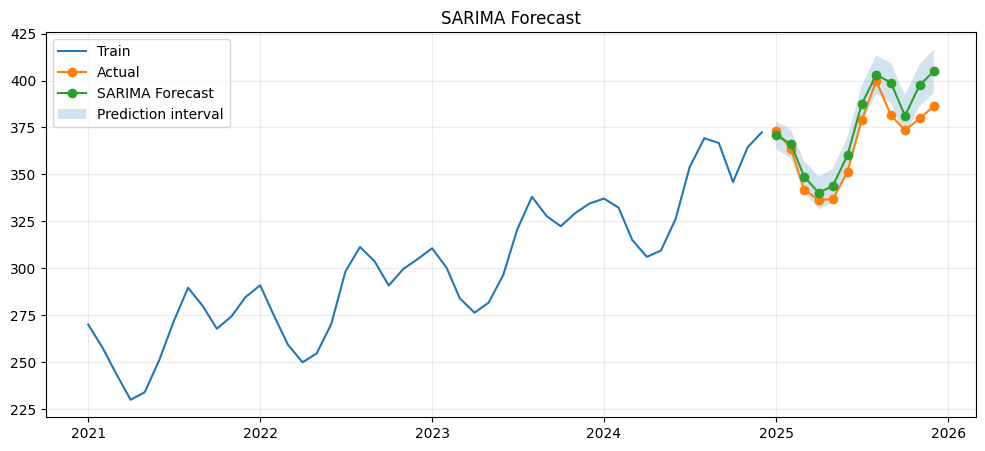

**[KR]** 12개월 hold-out 구간에서 MAE=8.73, RMSE=10.44입니다.<br>**[EN]** On the 12-month hold-out period, MAE=8.73 and RMSE=10.44.

In [17]:
# 마지막 12개월을 test로 두고 SARIMA 예측
train_ts = ts["mean_kwh"].iloc[:-12]
test_ts = ts["mean_kwh"].iloc[-12:]

sarima = SARIMAX(
    train_ts,
    order=(1,1,1),
    seasonal_order=(1,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc = sarima.get_forecast(steps=len(test_ts))
pred = fc.predicted_mean
ci = fc.conf_int()

mae = mean_absolute_error(test_ts, pred)
rmse = mean_squared_error(test_ts, pred) ** 0.5

plt.figure(figsize=(12,5))
plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(test_ts.index, test_ts, marker="o", label="Actual")
plt.plot(pred.index, pred, marker="o", label="SARIMA Forecast")
plt.fill_between(
    pred.index,
    ci.iloc[:,0],
    ci.iloc[:,1],
    alpha=0.2,
    label="Prediction interval"
)
plt.title("SARIMA Forecast")
plt.legend()
plt.show()

bilingual(
    f"12개월 hold-out 구간에서 MAE={mae:.2f}, RMSE={rmse:.2f}입니다.",
    f"On the 12-month hold-out period, MAE={mae:.2f} and RMSE={rmse:.2f}."
)

### Time Series Analysis 해석
- 분석단위: 하나의 연속된 집계 변수
- 핵심 질문: 과거 값과 계절성이 미래 값에 어떤 정보를 주는가?
- 대표도구: Decomposition, ACF/PACF, ARIMA/SARIMA, Forecasting

---
# 5. 네 가지 분석 비교

| 분석 | 반복 대상 | 핵심 단위 | 대표 질문 |
|---|---|---|---|
| Trend | 모집단 평균·분포 | 월별 집계 | 전체 수준이 어떻게 변하는가? |
| Panel | 같은 가구 | 가구 × 월 | 같은 가구 내부에서 무엇이 변하는가? |
| Cohort | 같은 사건 경험집단 | cohort × event time | 같은 시작점 이후 경로는 어떻게 다른가? |
| Time Series | 하나의 연속 변수 | 시간 | 자기의존·계절성·미래값은? |

## 가장 중요한 결론
> **먼저 무엇이 반복되는지를 확인하고, 그 다음 분석모형을 선택한다.**

In [18]:
# 최종 자동 요약표
comparison = pd.DataFrame([
    ["Trend Analysis", "Population mean/distribution", "Month summary", "Long-run trend / distribution change"],
    ["Panel Analysis", "Same households", "Household × Month", "Within-unit change / FE"],
    ["Cohort Analysis", "Same event groups", "Cohort × Event time", "Post-event path"],
    ["Time Series Analysis", "Continuous values of one aggregate variable", "Month", "Dependence / seasonality / forecast"]
], columns=["Design","Repeated unit","Analysis unit","Main purpose"])

display(comparison)

,Design,Repeated unit,Analysis unit,Main purpose
0,Trend Analysis,Population mean/distribution,Month summary,Long-run trend / distribution change
1,Panel Analysis,Same households,Household × Month,Within-unit change / FE
2,Cohort Analysis,Same event groups,Cohort × Event time,Post-event path
3,Time Series Analysis,Continuous values of one aggregate variable,Month,Dependence / seasonality / forecast
